# Spatial Filters Part 1

<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Spatial-Filters-Part-1" data-toc-modified-id="Spatial-Filters-Part-1-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Spatial Filters Part 1</a></span><ul class="toc-item"><li><span><a href="#What-is-filters?" data-toc-modified-id="What-is-filters?-1.1"><span class="toc-item-num">1.1&nbsp;&nbsp;</span>What is filters?</a></span></li><li><span><a href="#Linear-Noise-Smothing-Filters" data-toc-modified-id="Linear-Noise-Smothing-Filters-1.2"><span class="toc-item-num">1.2&nbsp;&nbsp;</span>Linear Noise Smothing Filters</a></span><ul class="toc-item"><li><span><a href="#Box-filter" data-toc-modified-id="Box-filter-1.2.1"><span class="toc-item-num">1.2.1&nbsp;&nbsp;</span>Box filter</a></span></li><li><span><a href="#Gaussian-Smoothing" data-toc-modified-id="Gaussian-Smoothing-1.2.2"><span class="toc-item-num">1.2.2&nbsp;&nbsp;</span>Gaussian Smoothing</a></span></li></ul></li><li><span><a href="#Boundary-issue-when-filtering" data-toc-modified-id="Boundary-issue-when-filtering-1.3"><span class="toc-item-num">1.3&nbsp;&nbsp;</span>Boundary issue when filtering</a></span></li><li><span><a href="#Non-Linear-Filters" data-toc-modified-id="Non-Linear-Filters-1.4"><span class="toc-item-num">1.4&nbsp;&nbsp;</span>Non-Linear Filters</a></span><ul class="toc-item"><li><span><a href="#Bilateral-filter-(edge-preserving,-and-noise-reducing-smoothing-filter)" data-toc-modified-id="Bilateral-filter-(edge-preserving,-and-noise-reducing-smoothing-filter)-1.4.1"><span class="toc-item-num">1.4.1&nbsp;&nbsp;</span>Bilateral filter (edge-preserving, and noise-reducing smoothing filter)</a></span></li></ul></li></ul></li></ul></div>

## What is filters?

- Applying filters to the image is a way to modify image. 
- Where we use more than one pixel to generate a new pixel value.
- Filters can be classified into linear and non linear filters.

## Linear Noise Smothing Filters

- <b>Box filter:</b> All members of this filter are the same.
- <b> Gaussian filter:</b> The weight of filter member depend on the location of the member. The center of the filter receive the maximum weigh and it decreases with distance from the center.

### Box filter

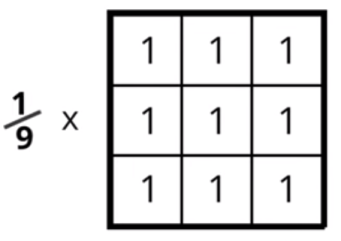

<class 'numpy.ndarray'>
(200, 200, 3)
[[[ 54  92  94]
  [ 48  76  88]
  [ 38  52  66]
  ...
  [ 60 106 108]
  [ 78 122 114]
  [100 142 128]]

 [[ 60 106 108]
  [ 48  76  88]
  [ 46  64  80]
  ...
  [ 84 110 108]
  [ 60  98  92]
  [ 56  84  78]]

 [[ 48  76  88]
  [ 60 106 108]
  [ 48  76  88]
  ...
  [ 60 106 108]
  [ 58  98 104]
  [100 166 156]]

 ...

 [[116 124 110]
  [152 146 132]
  [148 136 114]
  ...
  [102 100  90]
  [ 88 106  96]
  [ 74  82  82]]

 [[130 134 114]
  [148 158 120]
  [130 134 114]
  ...
  [ 84  94  88]
  [ 84 100  90]
  [ 84  94  88]]

 [[ 86  96  80]
  [ 76  76  70]
  [ 84  94  72]
  ...
  [ 42  50  56]
  [ 42  50  56]
  [ 42  50  56]]]


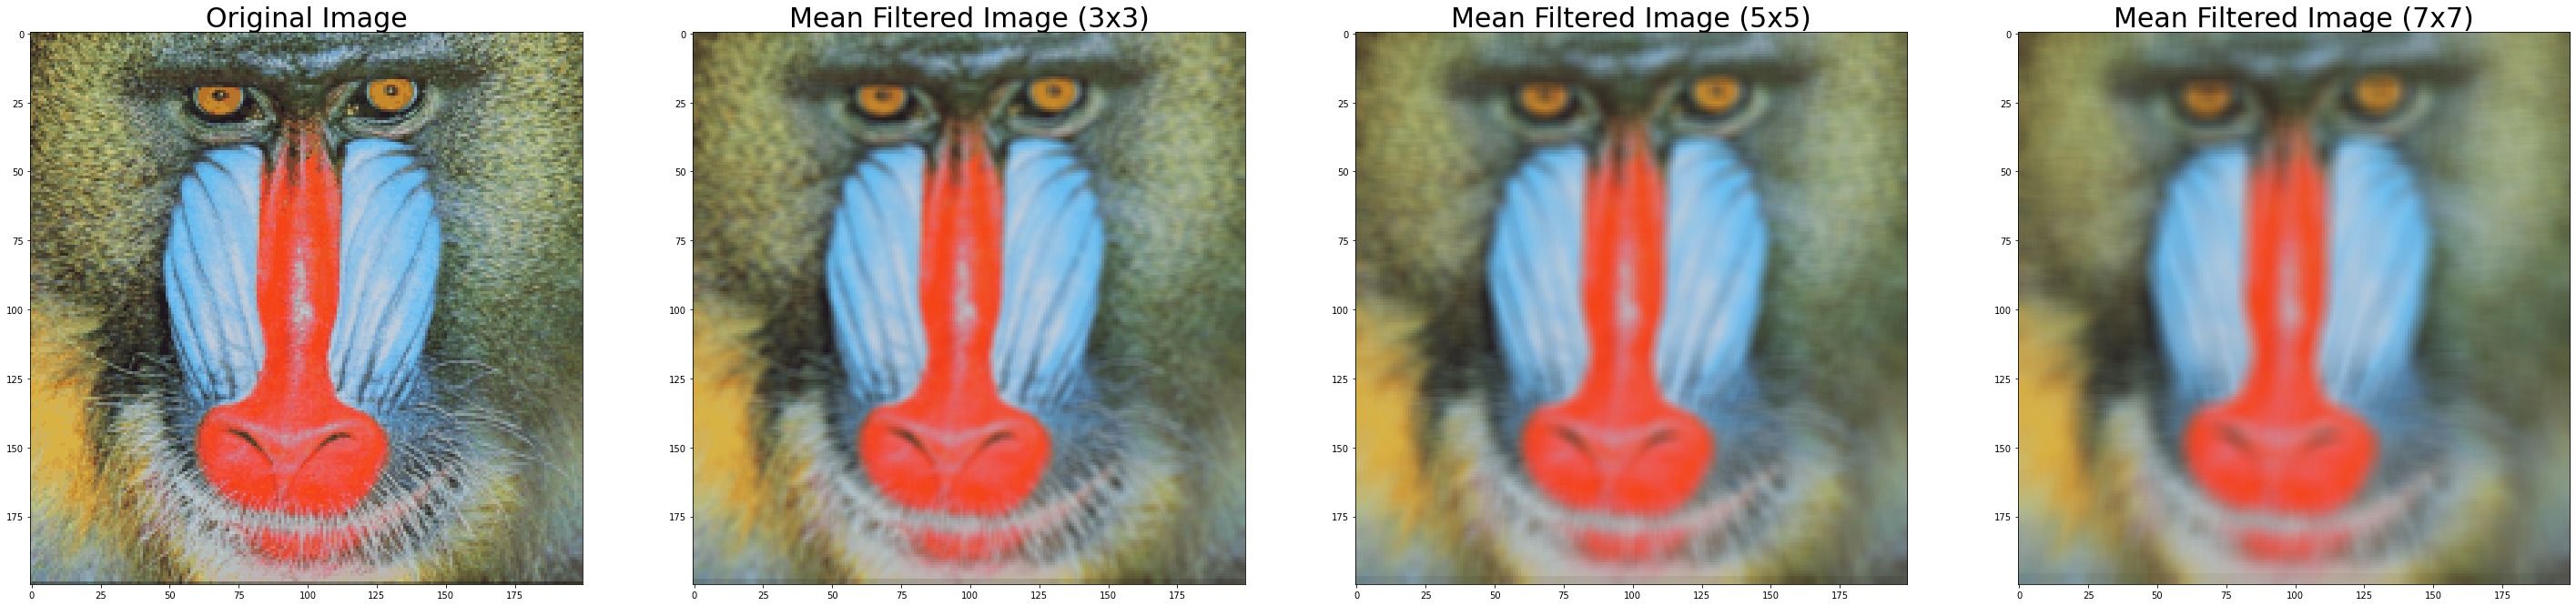

In [11]:
import cv2
import matplotlib.pyplot as plt

# Load the image
img = cv2.imread('baboon.png')
print(type(img))
print(img.shape)
print(img)

# Apply mean filter with kernel size 3x3
blur_3 = cv2.blur(img, (3, 3))


# Apply mean filter with kernel size 5x5
blur_5 = cv2.blur(img, (5, 5))

# Apply mean filter with kernel size 7x7
blur_7 = cv2.blur(img, (7, 7))

# Display the original and filtered images using Matplotlib
fig, axs = plt.subplots(1, 4, figsize=(50, 50))

# Note!! 
# CV2 -> BGR
# Plt -> RGB
axs[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
# axs[0].imshow(img)
axs[0].set_title('Original Image', fontsize=30)

axs[1].imshow(cv2.cvtColor(blur_3, cv2.COLOR_BGR2RGB))
axs[1].set_title('Mean Filtered Image (3x3)', fontsize=30)

axs[2].imshow(cv2.cvtColor(blur_5, cv2.COLOR_BGR2RGB))
axs[2].set_title('Mean Filtered Image (5x5)', fontsize=30)

axs[3].imshow(cv2.cvtColor(blur_7, cv2.COLOR_BGR2RGB))
axs[3].set_title('Mean Filtered Image (7x7)', fontsize=30)
plt.show()


Box filter: reduce the noise but make the image blur

### Gaussian Smoothing

By setting the standard deviation 𝛔, we can control until what certain extent we smooth the image. In other words, the higher the standard deviation gets the stronger effect of smoothing effect the image has.

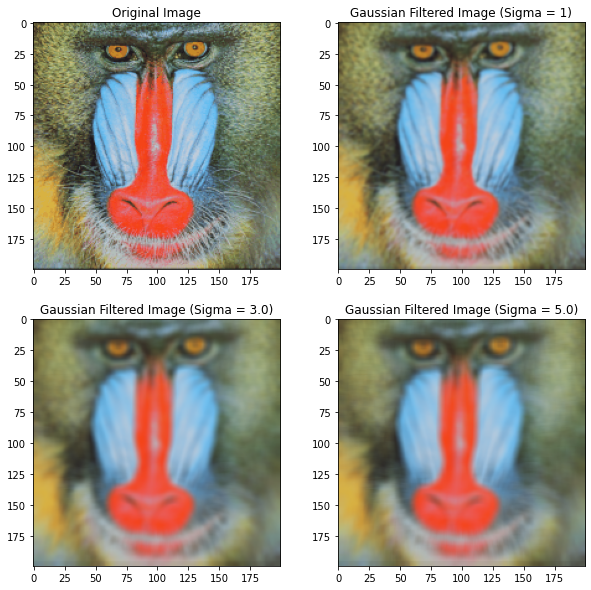

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image
img = cv2.imread('baboon.png')

# Define the kernel sizes and standard deviations
ksize = (7, 7)    # kernel size (width, height)
sigma1 = 1    # standard deviation for first Gaussian filter
sigma2 = 3.0      # standard deviation for second Gaussian filter
sigma3 = 5.0      # standard deviation for third Gaussian filter

# Apply Gaussian filters
blur1 = cv2.GaussianBlur(img, ksize, sigma1)
blur2 = cv2.GaussianBlur(img, ksize, sigma2)
blur3 = cv2.GaussianBlur(img, ksize, sigma3)

# Display the original and filtered images using Matplotlib
fig, axs = plt.subplots(2, 2, figsize=(10, 10))

axs[0, 0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axs[0, 0].set_title('Original Image')

axs[0, 1].imshow(cv2.cvtColor(blur1, cv2.COLOR_BGR2RGB))
axs[0, 1].set_title('Gaussian Filtered Image (Sigma = 1)')

axs[1, 0].imshow(cv2.cvtColor(blur2, cv2.COLOR_BGR2RGB))
axs[1, 0].set_title('Gaussian Filtered Image (Sigma = 3.0)')

axs[1, 1].imshow(cv2.cvtColor(blur3, cv2.COLOR_BGR2RGB))
axs[1, 1].set_title('Gaussian Filtered Image (Sigma = 5.0)')

plt.show()


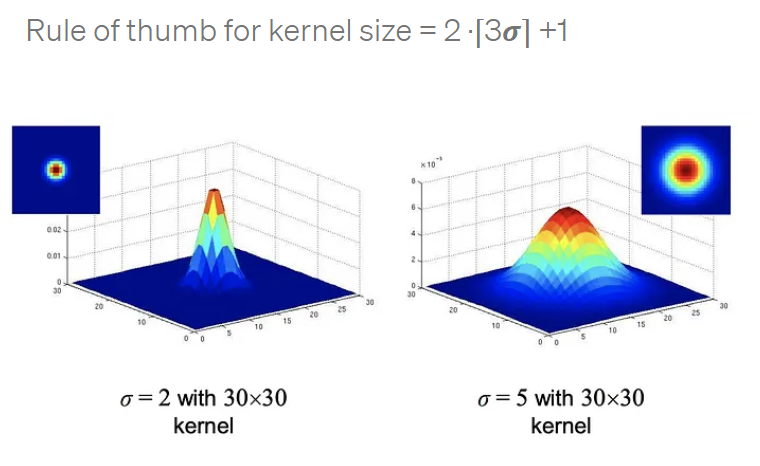

Reference: https://medium.com/jun94-devpblog/cv-2-gaussian-and-median-filter-separable-2d-filter-2d11ee022c66

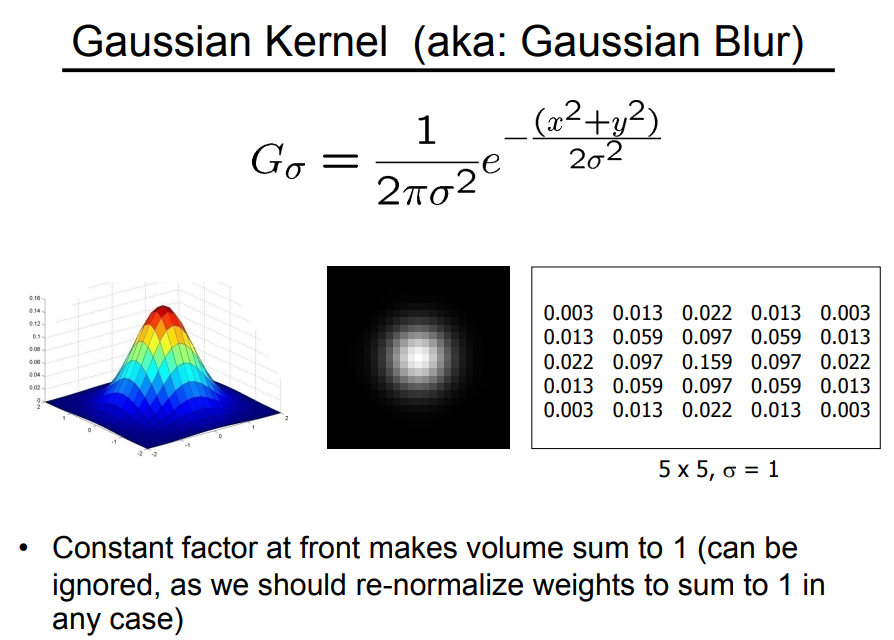

Some Notes on gaussian filter:
- if sigma is too large will be like a box filter
- if sigma is too small you have done nothing
- Usually better than box filter (bec it focuses on the most neighbouring pixels more than the further ones)
- Disadvantage of gaussian appears in the edges 

 ## Boundary issue when filtering

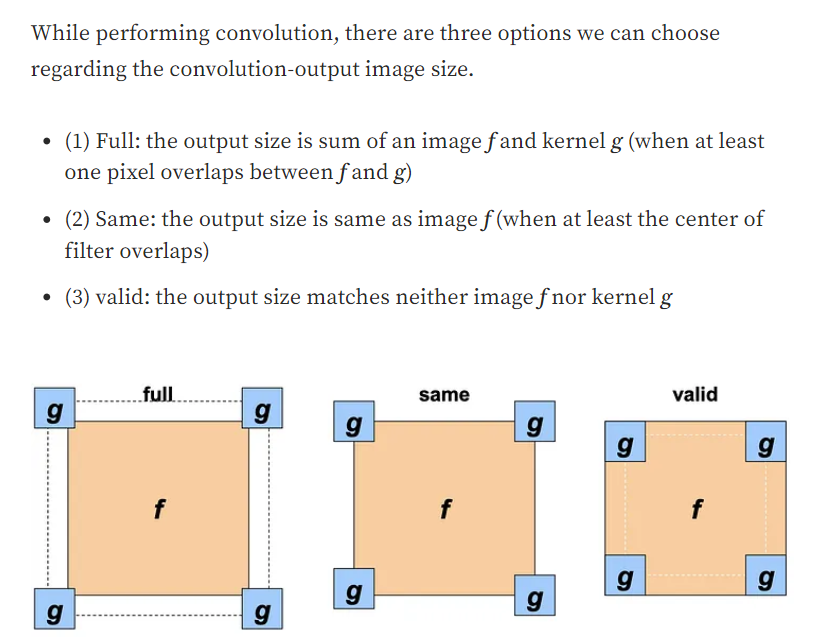

## Non-Linear Filters

### Bilateral filter (edge-preserving, and noise-reducing smoothing filter)

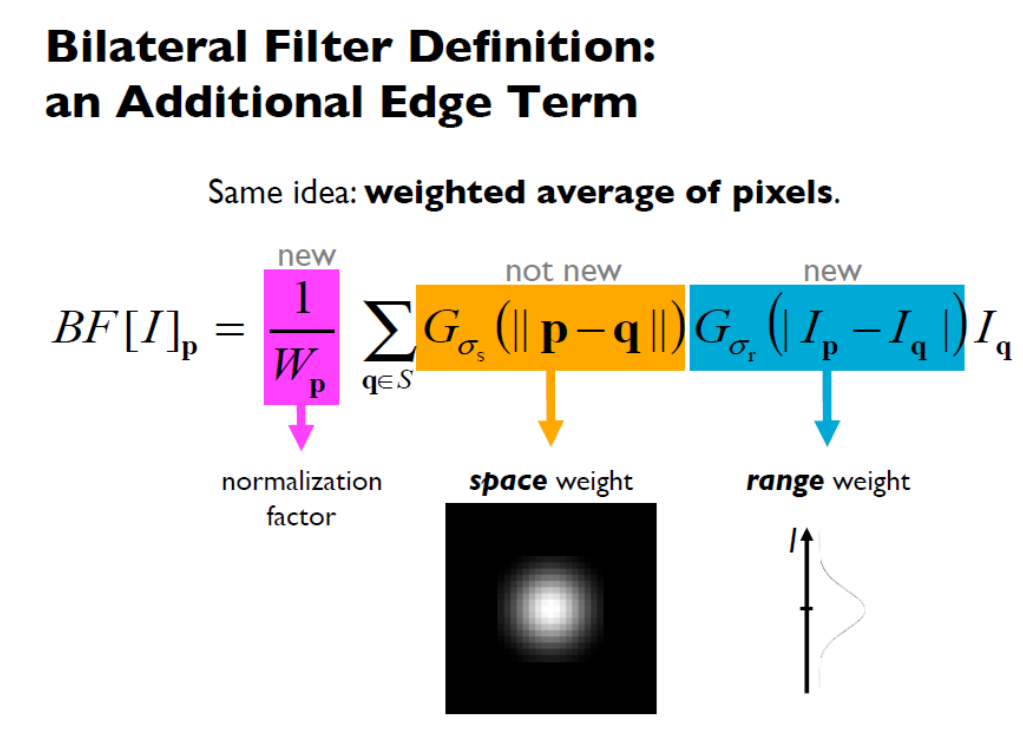